In [18]:
import pandas as pd

df = pd.read_pickle('df_feature_engineering.pkl')

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (1166, 216)
X_test  : (292, 216)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE : {rmse_lr:.4f} | R² : {r2_lr:.4f}")

Linear Regression — RMSE : 0.1308 | R² : 0.8985


In [21]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
model_ridge = Ridge(alpha=10)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge — RMSE : {rmse_ridge:.4f} | R² : {r2_ridge:.4f}")

# Lasso
model_lasso = Lasso(alpha=0.001)
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso — RMSE : {rmse_lasso:.4f} | R² : {r2_lasso:.4f}")

Ridge — RMSE : 0.1229 | R² : 0.9104
Lasso — RMSE : 0.1196 | R² : 0.9151


In [22]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest — RMSE : {rmse_rf:.4f} | R² : {r2_rf:.4f}")

Random Forest — RMSE : 0.1458 | R² : 0.8740


In [23]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_xgb = model_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost — RMSE : {rmse_xgb:.4f} | R² : {r2_xgb:.4f}")

XGBoost — RMSE : 0.1284 | R² : 0.9022


In [31]:
models = {
    'Linear Regression': y_pred_lr,
    'Ridge':             y_pred_ridge,
    'Lasso':             y_pred_lasso,
    'Random Forest':     y_pred_rf,
    'XGBoost':           y_pred_xgb
}

resultats = []
for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = np.mean(np.abs(y_test - y_pred))
    resultats.append({
        'Modèle': name,
        'RMSE': round(rmse, 4),
        'MAE':  round(mae, 4),
        'R²':   round(r2, 4)
    })

df_results = pd.DataFrame(resultats).sort_values('RMSE')
print(df_results.to_string(index=False))

           Modèle   RMSE    MAE     R²
            Lasso 0.1196 0.0820 0.9151
            Ridge 0.1229 0.0831 0.9104
          XGBoost 0.1284 0.0836 0.9022
Linear Regression 0.1308 0.0899 0.8985
    Random Forest 0.1458 0.0975 0.8740


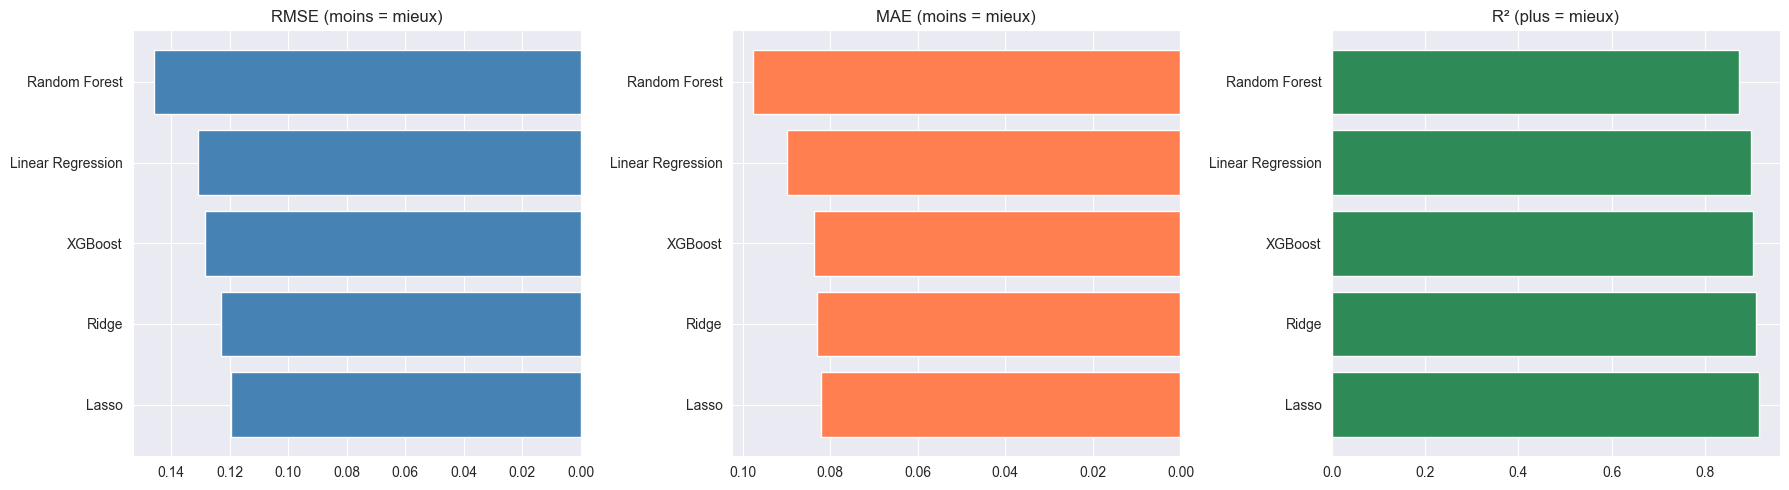

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axes[0].barh(df_results['Modèle'], df_results['RMSE'], color='steelblue')
axes[0].set_title('RMSE (moins = mieux)')
axes[0].invert_xaxis()

# MAE
axes[1].barh(df_results['Modèle'], df_results['MAE'], color='coral')
axes[1].set_title('MAE (moins = mieux)')
axes[1].invert_xaxis()

# R²
axes[2].barh(df_results['Modèle'], df_results['R²'], color='seagreen')
axes[2].set_title('R² (plus = mieux)')

plt.tight_layout()
plt.show()

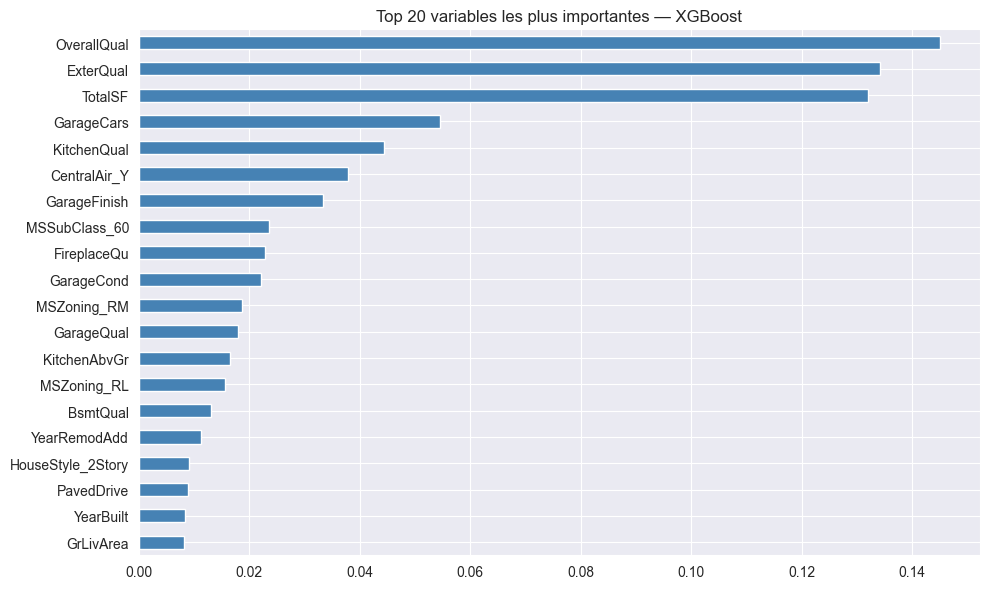

In [33]:
importances = pd.Series(
    model_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 20 variables les plus importantes — XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

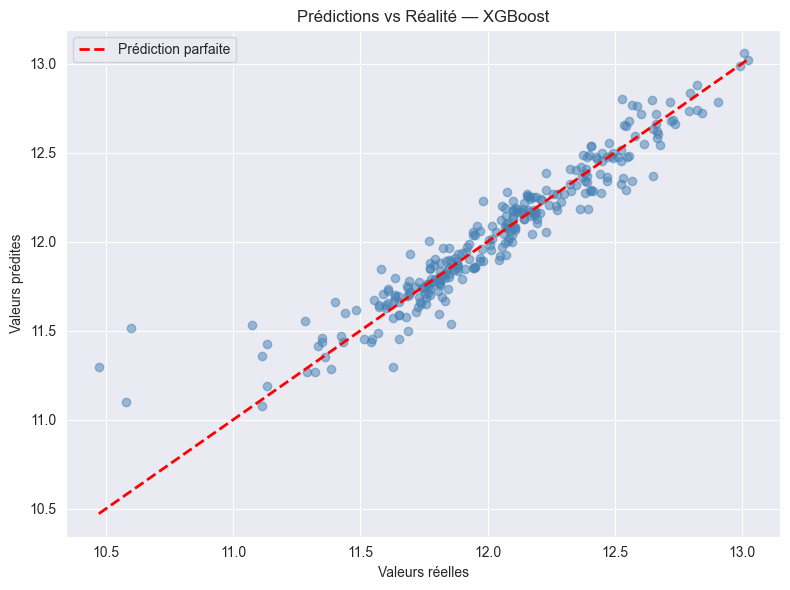

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title('Prédictions vs Réalité — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()